# Time Series in Environmental Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_url = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_daily_mlo.csv'
dat = pd.read_csv(data_url, comment='#', header=None)
# dat = pd.read_csv('data/co2_daily_mlo.csv', comment='#', header=None)  # if working offline, use local file
dat.columns = ['year', 'month', 'day', 'decimal_date', 'pCO2']

In [3]:
# subset = dat[dat['year'] >= (dat['year'].max() - 1)]
subset = dat

Text(0.5, 0, 'Year')

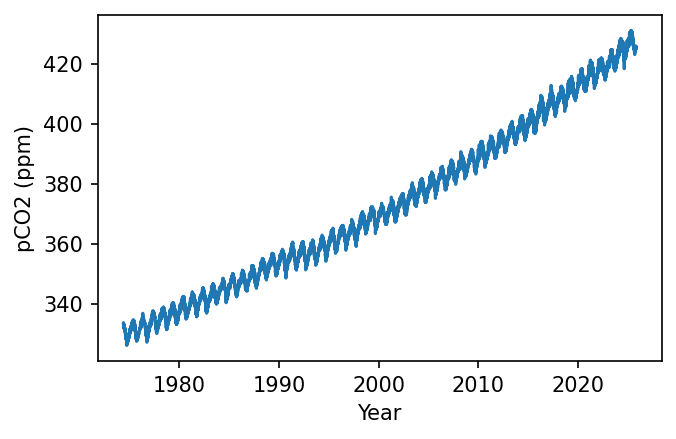

In [4]:
fig, ax = plt.subplots()
ax.plot(subset['decimal_date'], subset['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')

In [5]:
from statsmodels.formula.api import ols, glm

                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                 8.483e+05
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:12:22   Log-Likelihood:                -43012.
No. Observations:               15761   AIC:                         8.603e+04
Df Residuals:                   15759   BIC:                         8.604e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -3378.4856      4.075   -829.171   

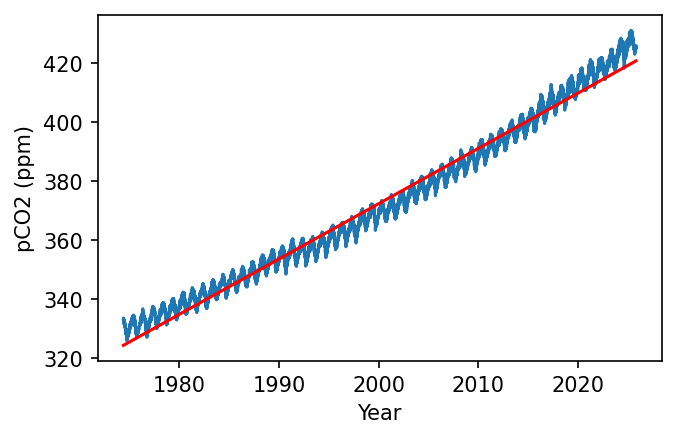

In [6]:
naive_model = ols('pCO2 ~ decimal_date', data=subset).fit()
print(naive_model.summary())

fig, ax = plt.subplots()
ax.plot(subset['decimal_date'], subset['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')
ax.plot(subset['decimal_date'], naive_model.fittedvalues, color='red')

                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 4.175e+05
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:12:22   Log-Likelihood:                -39986.
No. Observations:               15761   AIC:                         7.998e+04
Df Residuals:                   15757   BIC:                         8.001e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -3378.9090      3.363  -1004.691   

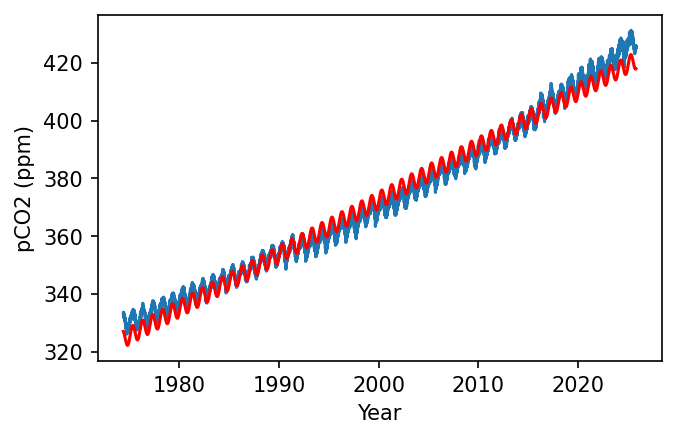

In [7]:
subset['sin_annual'] = np.sin(2 * np.pi * subset['decimal_date'])
subset['cos_annual'] = np.cos(2 * np.pi * subset['decimal_date'])

harmonic_model_formula = 'pCO2 ~ decimal_date + sin_annual + cos_annual'
harmonic_model = ols(harmonic_model_formula, data=subset).fit()
print(harmonic_model.summary())

fig, ax = plt.subplots()
ax.plot(subset['decimal_date'], subset['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')
ax.plot(subset['decimal_date'], harmonic_model.fittedvalues, color='red')

                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     1234.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:12:23   Log-Likelihood:                -39986.
No. Observations:               15761   AIC:                         7.998e+04
Df Residuals:                   15757   BIC:                         8.001e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -3378.9090    161.224    -20.958   

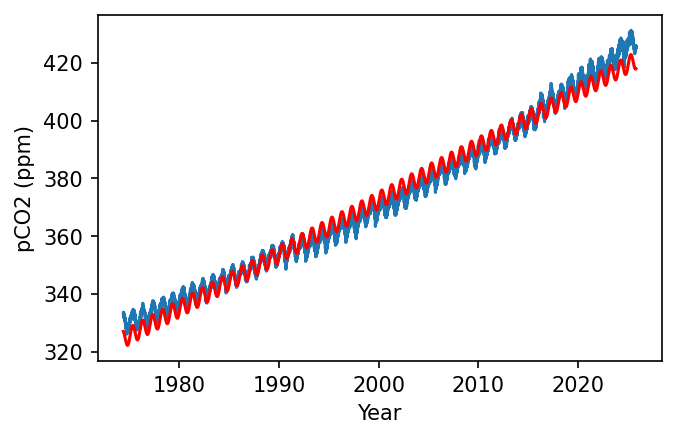

In [8]:
harmonic_model_formula = 'pCO2 ~ decimal_date + sin_annual + cos_annual'
hac_harmonic_model = ols(harmonic_model_formula, data=subset).fit(cov_type='HAC', cov_kwds={'maxlags': subset.shape[0] // 4})
print(hac_harmonic_model.summary())

fig, ax = plt.subplots()
ax.plot(subset['decimal_date'], subset['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')
ax.plot(subset['decimal_date'], harmonic_model.fittedvalues, color='red')

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   pCO2   No. Observations:                15761
Model:                            GLM   Df Residuals:                    15757
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                          9.3599
Method:                          IRLS   Log-Likelihood:                -39986.
Date:                Mon, 03 Nov 2025   Deviance:                   1.4748e+05
Time:                        20:12:23   Pearson chi2:                 1.47e+05
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -3378.9090      3.363  -1004.691   

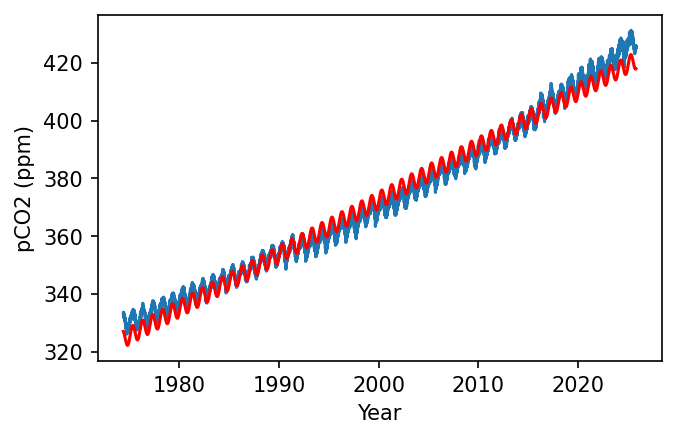

In [9]:
glm_harmonic_model = glm(harmonic_model_formula, data=subset).fit()
print(glm_harmonic_model.summary())

fig, ax = plt.subplots()
ax.plot(subset['decimal_date'], subset['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')
ax.plot(subset['decimal_date'], glm_harmonic_model.fittedvalues, color='red')

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   pCO2   No. Observations:                15761
Model:                            GLM   Df Residuals:                    15757
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                          9.3599
Method:                          IRLS   Log-Likelihood:                -39986.
Date:                Mon, 03 Nov 2025   Deviance:                   1.4748e+05
Time:                        20:12:23   Pearson chi2:                 1.47e+05
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -3378.9090    161.224    -20.958   

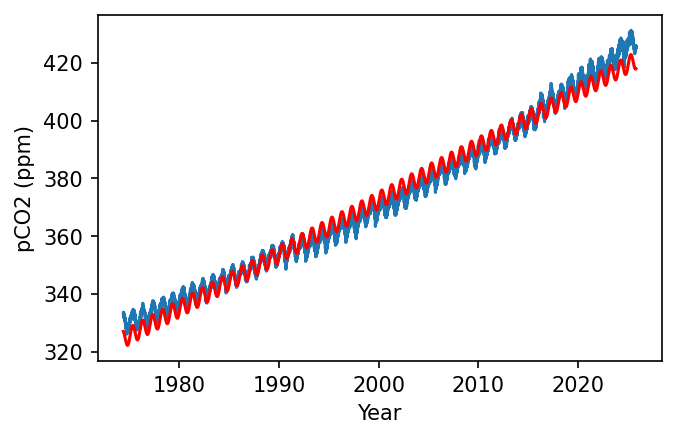

In [10]:
hac_glm_harmonic_model = glm(harmonic_model_formula, data=subset).fit(cov_type='HAC', cov_kwds={'maxlags': subset.shape[0] // 4})
print(hac_glm_harmonic_model.summary())

fig, ax = plt.subplots()
ax.plot(subset['decimal_date'], subset['pCO2'])
ax.set_ylabel('pCO2 (ppm)')
ax.set_xlabel('Year')
ax.plot(subset['decimal_date'], hac_glm_harmonic_model.fittedvalues, color='red')

                           GLSAR Regression Results                           
Dep. Variable:                   pCO2   R-squared:                       0.442
Model:                          GLSAR   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     4158.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:12:23   Log-Likelihood:                -14107.
No. Observations:               15760   AIC:                         2.822e+04
Df Residuals:                   15756   BIC:                         2.825e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -3390.9446     33.977    -99.802   

Text(0, 0.5, 'pCO2 (ppm)')

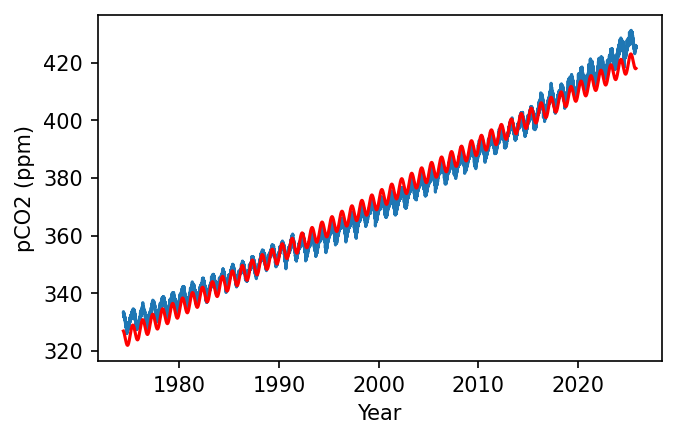

In [11]:
import patsy
from statsmodels.regression.linear_model import GLSAR

y, X = patsy.dmatrices(harmonic_model_formula, data=subset, return_type='dataframe')
glsar = GLSAR(y, X, rho=1)               # AR(1) errors
glsar_res = glsar.iterative_fit(10)      # iterate to estimate rho
print(glsar_res.summary())

fig, ax = plt.subplots()
ax.plot(subset['decimal_date'], subset['pCO2'])
ax.plot(subset['decimal_date'], np.asarray(glsar_res.fittedvalues).ravel(), color='red')
ax.set_xlabel('Year'); ax.set_ylabel('pCO2 (ppm)')

                               SARIMAX Results                                
Dep. Variable:          pCO2_centered   No. Observations:                15761
Model:               SARIMAX(1, 0, 0)   Log Likelihood              -14106.693
Date:                Mon, 03 Nov 2025   AIC                          28225.387
Time:                        20:12:26   BIC                          28271.378
Sample:                             0   HQIC                         28240.609
                              - 15761                                         
Covariance Type:                  opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept                -0.0002      0.005     -0.046      0.963      -0.010       0.009
decimal_date_centered     1.8817      0.018    106.147      0.000       1.847       1.916
sin_annu

Text(0, 0.5, 'pCO2 (ppm)')

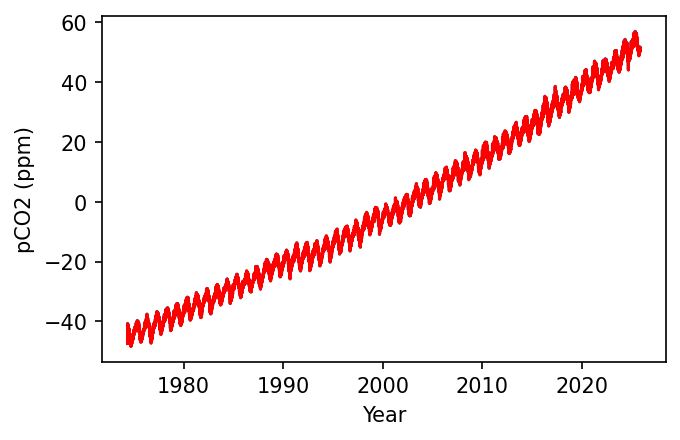

In [12]:
import statsmodels.api as sm

subset['decimal_date_centered'] = subset['decimal_date'] - subset['decimal_date'].mean()
subset['pCO2_centered'] = subset['pCO2'] - subset['pCO2'].mean()

exog = subset[['decimal_date_centered','sin_annual','cos_annual']]  # consider centering decimal_date
sarimax = sm.tsa.SARIMAX(
    subset['pCO2_centered'], exog=exog, order=(1,0,0),trend='c',
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
print(sarimax.summary())

fig, ax = plt.subplots()
ax.plot(subset['decimal_date'], subset['pCO2_centered'])
ax.plot(subset['decimal_date'], sarimax.fittedvalues, color='red')
ax.set_xlabel('Year'); ax.set_ylabel('pCO2 (ppm)')

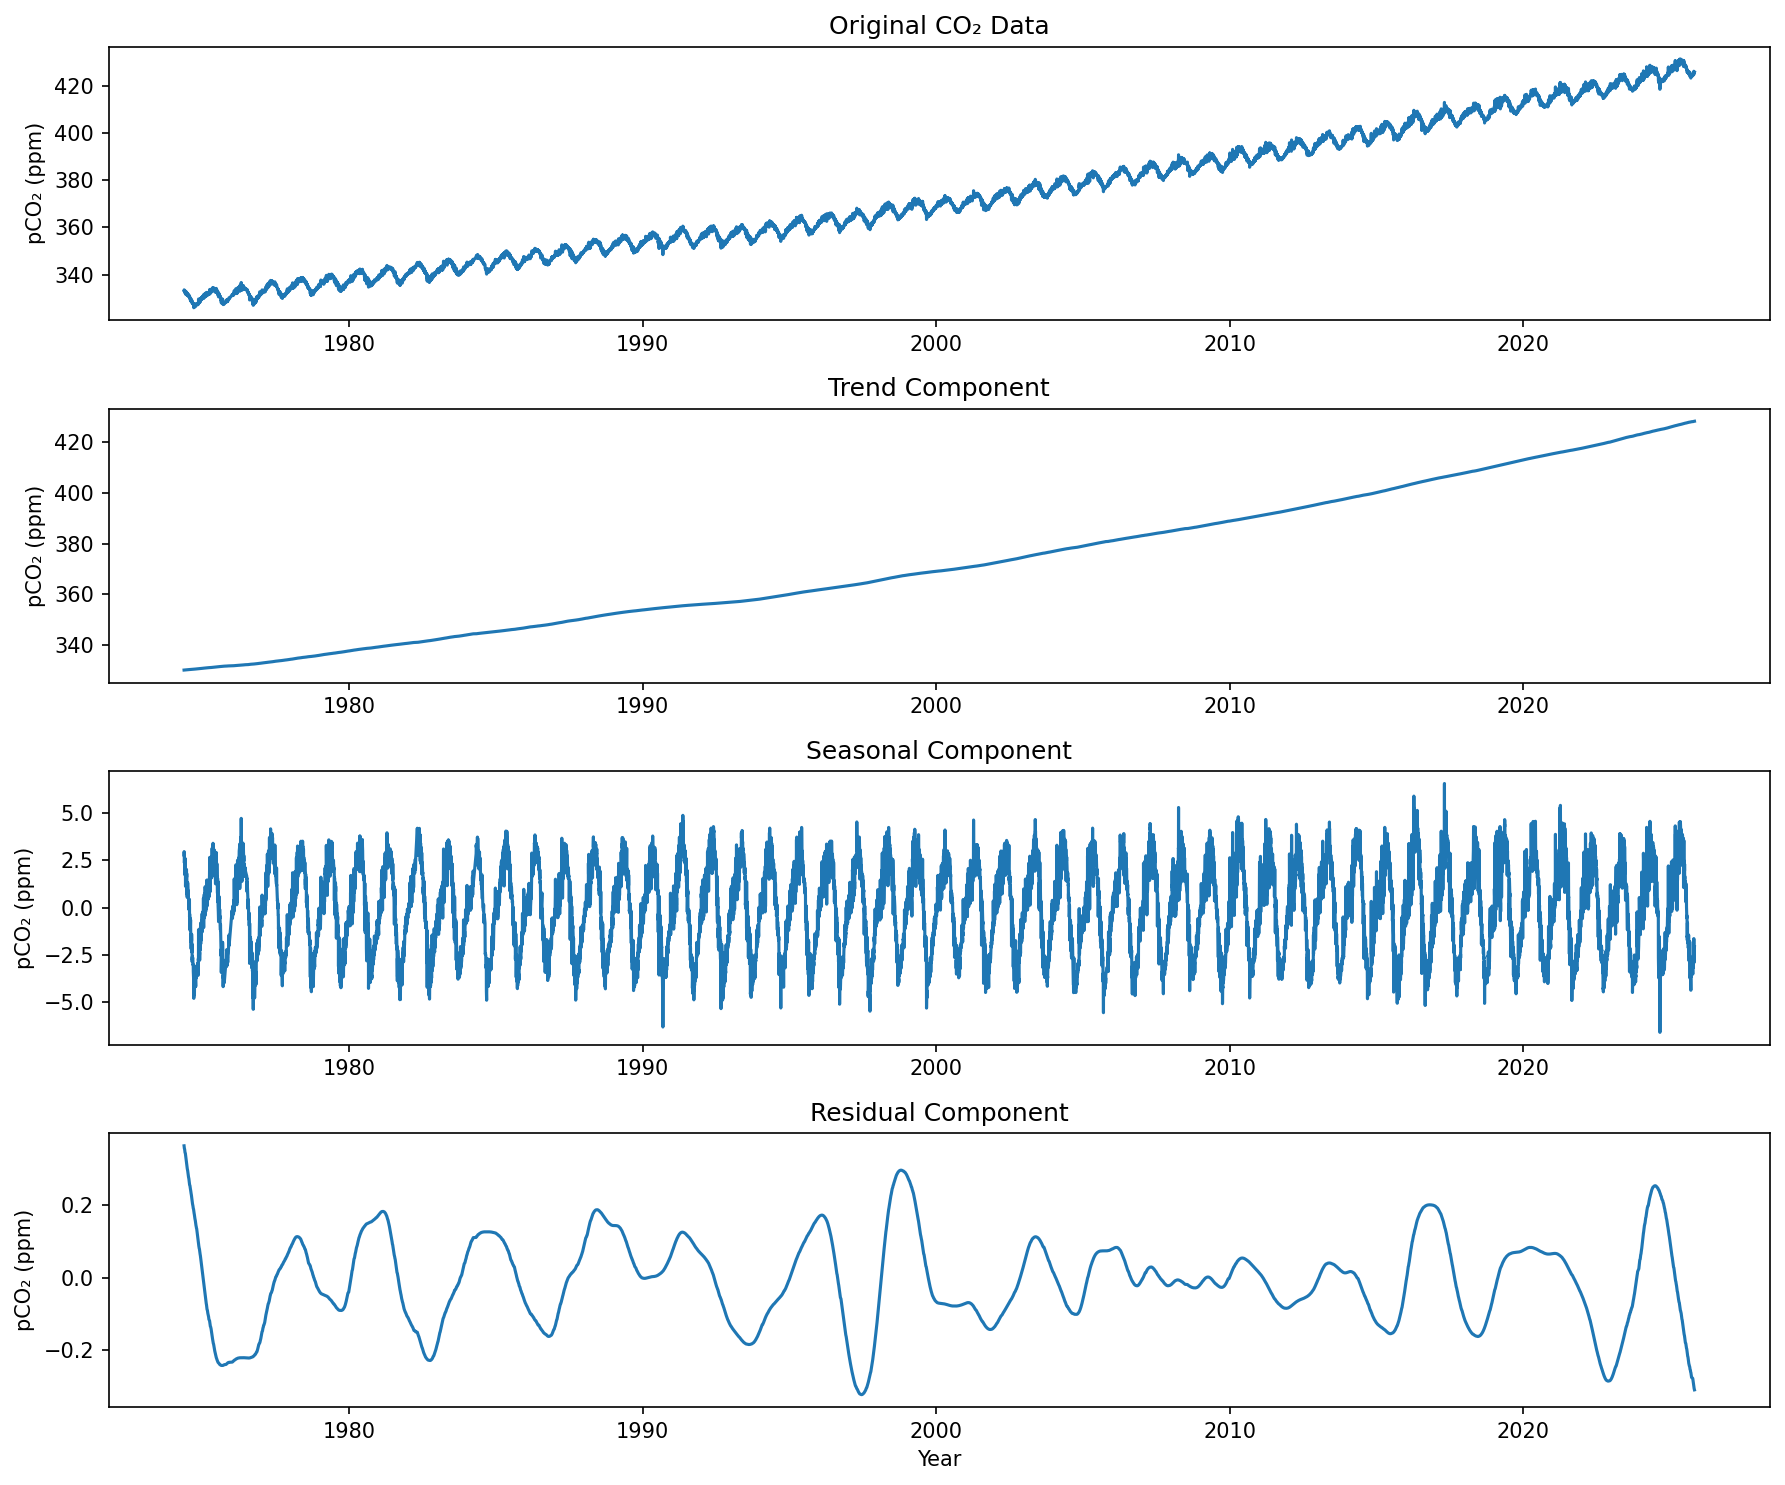

STL Decomposition Summary:
Trend range: 330.3 to 428.1 ppm
Seasonal range: -6.6 to 6.5 ppm
Residual std: 0.12 ppm


In [ ]:
from statsmodels.tsa.seasonal import STL

# STL decomposition - need to set frequency for seasonal period
# For daily data with annual cycle, use freq=365
stl = STL(subset['pCO2'], seasonal=3, period=365)  # seasonal=X controls smoothing, larger = smoother
result = stl.fit()

# Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# Original data
axes[0].plot(subset['decimal_date'], subset['pCO2'])
axes[0].set_title('Original CO₂ Data')
axes[0].set_ylabel('pCO₂ (ppm)')

# Trend component
axes[1].plot(subset['decimal_date'], result.trend)
axes[1].set_title('Trend Component')
axes[1].set_ylabel('pCO₂ (ppm)')

# Seasonal component
axes[2].plot(subset['decimal_date'], result.seasonal)
axes[2].set_title('Seasonal Component')
axes[2].set_ylabel('pCO₂ (ppm)')

# Residual component
axes[3].plot(subset['decimal_date'], result.resid)
axes[3].set_title('Residual Component')
axes[3].set_ylabel('pCO₂ (ppm)')
axes[3].set_xlabel('Year')

plt.tight_layout()
plt.show()

# Print summary stats
print("STL Decomposition Summary:")
print(f"Trend range: {result.trend.min():.1f} to {result.trend.max():.1f} ppm")
print(f"Seasonal range: {result.seasonal.min():.1f} to {result.seasonal.max():.1f} ppm")
print(f"Residual std: {result.resid.std():.2f} ppm")